In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

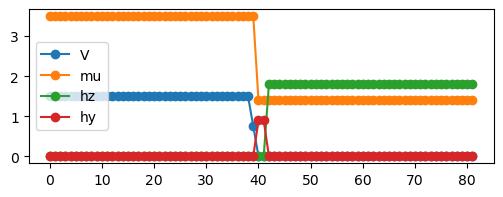

In [3]:
widthS = 40
widthF1 = 2
widthF2 = 40
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 3.5 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:] = muF

h0 = 0.9 * t
hz = np.zeros_like(mu)
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0
hz[widthS+widthF1:widthS+widthF1+widthF2] = 2*h0 

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2
U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [ ]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                hx=hy)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.6532474740473565
Relative error: 653247474047.3564
Average old: 0j
Average: (-0.05019064713709943+0j)
F_xplus:
Absolute error: 0.22301922307409353
Relative error: 4931866666.061678
Average old: (0.09629629629629628+0j)
Average: (0.07929627769616494+0j)
F_xmin:
Absolute error: 0.2656792989721868
Relative error: 265679298972.18677
Average old: 0j
Average: (0.020337038387468327+0j)
F_yplus:
Absolute error: 0.31654065922236574
Relative error: 15651264480.883097
Average old: (0.048780487804878044+0.048780487804878044j)
Average: (0.05047604358830756+0.025165821078557873j)
F_ymin:
Absolute error: 0.31654065922236574
Relative error: 15651264480.883097
Average old: (0.048780487804878044-0.048780487804878044j)
Average: (0.05047604358830756-0.025165821078557873j)
Fuu_xplus:
Absolute error: 0.015620939491168273
Relative error: 15620939491.168274
Average old: 0j
Average: (-0.00040860309658098806+0j)
Fuu_xmin:
Absolute error: 0.015620939491167898
Relative error: 15620939491.167

KeyboardInterrupt: 

In [ ]:
F, Fuu, Fdd = H.get_correlations()


In [ ]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

# axs.plot(x, np.real(F_swave), label=r"$\uparrow\downarrow -\downarrow\uparrow$", color='blue')
axs.plot(x, np.abs(Fuu.py), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='red')
# axs.plot(x, np.imag(Fdd.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='green')
axs.plot(x, np.abs(Fuu.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='purple')

axs.set_xlabel("x", fontsize=15)
axs.set_xlim(-40, 40)
plt.show()

NameError: name 'np' is not defined